# 03 — Feature Engineering
**Aviation Safety Risk Prediction — NTSB + NOAA Dataset**

This notebook turns the cleaned dataset produced by NB01 (`data/processed/ntsb_clean_final.csv`)
into model-ready matrices, and saves every artefact used downstream by NB04, NB05 **and the Flask API**.

### Single source of truth
All row-level transformations (anomaly fixes, derived features, log transforms, column groups,
train/val/test split) live in **`backend/utils/feature_engineering.py`** and are *imported* here.
The backend applies the very same functions at inference time, so a prediction served by the API
sees exactly the features the model was trained on.
`backend/tests/test_feature_parity.py` checks this bit-for-bit against `outputs/X_test.csv`.

### Pipeline
1. Load the cleaned dataset
2. Anomaly fixes (`afm_hrs == 0`, gust without wind) and category clean-up
3. `acft_make` consolidation (top 25 makes + `OTHER`)
4. Derived features (weather flags, maintenance ratio, cyclical time, aircraft age)
5. Log transforms
6. Column groups and **target-leakage audit** (post-accident variables and missingness
   indicators are excluded)
7. **Temporal** split: train 2008–2018 · validation 2019–2021 · test 2022 onwards
8. `ColumnTransformer` (imputation, one-hot / ordinal encoding, scaling) — fitted on train only
9. `VarianceThreshold` · 10. Sanity checks · 11. Class weights · 12. Save artefacts

### Outputs (`notebooks/outputs/`)
`X_{train,val,test}.csv`, `y_{train,val,test}.csv`, `preprocessing_pipeline.pkl`,
`variance_threshold.pkl`, `feature_names.csv`, `class_weights.pkl`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, joblib, os, sys
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold

# Shared feature-engineering module (also used by the Flask API and seed_mongo.py)
sys.path.insert(0, os.path.abspath('../backend'))
from utils.feature_engineering import (
    BINARY_YN_COLS, NUMERIC_BINARY_COLS, OHE_COLS, OHE_HIGH_COLS, ORDINAL_COLS, NUMERIC_COLS,
    FEATURE_COLS, LEAKAGE_COLS, MISSING_INDICATOR_COLS, LOG_COLS, INJURY_ORDER, TARGET_COL,
    TOP_MAKES, VAL_START_YEAR, TEST_START_YEAR,
    compute_top_makes, engineer_features, select_model_features, split_positions,
)

OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 1. Load & Quick Inspect

In [2]:
df = pd.read_csv('../data/processed/ntsb_clean_final.csv', low_memory=False)
print(f'Shape: {df.shape}')
print(f'\nTarget distribution:')
print(df['ev_highest_injury'].value_counts())
print(f'\nClass imbalance NONE/FATL: {df["ev_highest_injury"].value_counts()["NONE"] / df["ev_highest_injury"].value_counts()["FATL"]:.2f}x')


Shape: (36260, 105)

Target distribution:
ev_highest_injury
NONE    19425
FATL     7496
MINR     4919
SERS     4420
Name: count, dtype: int64

Class imbalance NONE/FATL: 2.59x


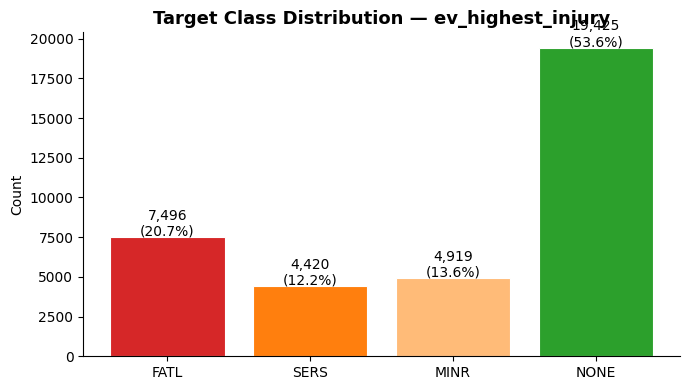

In [3]:
# Visual: target distribution
fig, ax = plt.subplots(figsize=(7, 4))
order  = ['FATL', 'SERS', 'MINR', 'NONE']
colors = ['#d62728', '#ff7f0e', '#ffbb78', '#2ca02c']
vc = df['ev_highest_injury'].value_counts()[order]
ax.bar(order, vc.values, color=colors, edgecolor='white', linewidth=0.8)
for i, v in enumerate(vc.values):
    ax.text(i, v + 80, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)
ax.set_title('Target Class Distribution — ev_highest_injury', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
sns.despine()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/target_distribution.png', dpi=150)
plt.show()


## 2. Anomaly Detection & Fixes
Two inconsistencies remain after NB01 (the `crew_age` clamp is already done in NB01 §11):
- **`afm_hrs == 0`** (total airframe hours) while not flagged as missing: impossible for an aircraft
  that has flown → set to `NaN`, imputed later by the median.
- **NOAA gust reported while the mean wind is 0**: the mean wind takes the gust value.

Categorical values that differ only by surrounding whitespace (`"UNK"` vs `"UNK "`, trailing
`\r\n` in free-text fields) are also merged.

All the fixes of sections 2 to 5 are applied by **one call to `engineer_features()`** (cell below);
the following cells only *inspect* what it did, comparing `df_raw` (before) and `df` (after).

In [4]:
# ── 2.1 Verify crew_age is already clean (from NB01) ─────────────────────
print('=== crew_age verification (should be clean from NB01) ===')
print(f'  crew_age < 16 : {(df["crew_age"] < 16).sum()} rows  (expected 0)')
print(f'  crew_age > 100: {(df["crew_age"] > 100).sum()} rows  (expected 0)')
print(f'  Range         : [{df["crew_age"].min():.0f}, {df["crew_age"].max():.0f}]')


=== crew_age verification (should be clean from NB01) ===
  crew_age < 16 : 0 rows  (expected 0)
  crew_age > 100: 0 rows  (expected 0)
  Range         : [16, 98]


In [5]:
# ── Apply the shared feature engineering (sections 2 to 5) ───────────────────
df_raw = df.copy()                       # kept for before / after inspection
top_makes = compute_top_makes(df_raw)    # the 25 most frequent makes of the dataset
assert set(top_makes) == set(TOP_MAKES), 'TOP_MAKES in feature_engineering.py is out of date'
df = engineer_features(df_raw, top_makes)

# §2.2 — afm_hrs == 0 without the "missing" flag → NaN
n_zero_hrs = ((df_raw['afm_hrs'] == 0) & (df_raw['is_missing_afm_hrs'] == 0)).sum()
print(f'afm_hrs == 0 (not flagged) replaced by NaN : {n_zero_hrs} rows')

afm_hrs == 0 (not flagged) replaced by NaN : 47 rows


In [6]:
# §2.3 — NOAA gust present but mean wind == 0 → mean wind takes the gust value
n_gust_fix = (df_raw['noaa_gust_knots'].notna() & (df_raw['noaa_wind_knots'] == 0)).sum()
print(f'noaa_wind_knots set to the gust value     : {n_gust_fix} rows')

# §1 — categories that only differed by whitespace are now merged
for col in ['type_fly', 'med_crtf_vldty', 'med_crtf_limit']:
    print(f'{col:16s}: {df_raw[col].nunique():>5} → {df[col].nunique():>5} distinct values after strip')

noaa_wind_knots set to the gust value     : 0 rows
type_fly        :    24 →    22 distinct values after strip
med_crtf_vldty  :     7 →     7 distinct values after strip
med_crtf_limit  :  2000 →  1927 distinct values after strip


## 3. `acft_make` Consolidation
Manufacturer names are upper-cased, stripped and de-aliased (`CIRRUS DESIGN CORP` → `CIRRUS`...).
Only the 25 most frequent makes are kept; the long tail becomes `OTHER`, which keeps the one-hot
encoding compact and avoids categories seen only a handful of times.

In [7]:
print(f'{len(top_makes)} makes kept, others grouped as OTHER')
print(df['acft_make_grouped'].value_counts())

25 makes kept, others grouped as OTHER
acft_make_grouped
OTHER             11621
CESSNA             8723
PIPER              5150
BEECH              1973
BOEING             1594
ROBINSON           1226
BELL                915
CIRRUS              600
AIR TRACTOR         486
MOONEY              429
AIRBUS              372
DE HAVILLAND        282
SCHWEIZER           253
BELLANCA            245
MAULE               236
EMBRAER             234
AERONCA             232
HUGHES              228
DIAMOND             219
BOMBARDIER          202
VANS                200
EUROCOPTER          191
CHAMPION            190
STINSON             160
LUSCOMBE            155
NORTH AMERICAN      144
Name: count, dtype: int64


## 4. Derived Features
Domain-driven features computed by `engineer_features()`:

| Feature | Definition | Rationale |
|---|---|---|
| `adverse_weather` | fog, rain, snow or thunder reported by NOAA | degraded meteorological conditions |
| `poor_visibility` | visibility < 5 km | below ICAO VMC minima |
| `high_wind` | NOAA mean wind > 25 kt | beyond typical light-aircraft crosswind limits |
| `extreme_temp` | temperature < −20 °C or > 35 °C | icing / density-altitude effects |
| `td_spread`, `fog_risk` | temperature − dew point, and spread < 3 °C | fog and carburettor-icing risk |
| `is_imc` | instrument meteorological conditions | flight without visual references |
| `maintenance_ratio` | share of airframe hours flown since the last inspection | maintenance exposure |
| `hour/dow/month_sin/cos` | cyclical encoding of time | 23 h and 0 h are neighbours |
| `acft_age` | event year − manufacturing year, clipped to [0, 80] | ageing airframe |
| `gust_excess` | gust − mean wind (≥ 0) | turbulence intensity |

In [8]:
print('Weather flags (positive rows):')
for col in ['adverse_weather', 'poor_visibility', 'high_wind', 'extreme_temp', 'fog_risk', 'is_imc']:
    print(f'  {col:16s}: {df[col].sum():>6,}  ({df[col].mean()*100:.1f} %)')

Weather flags (positive rows):
  adverse_weather : 12,375  (34.1 %)
  poor_visibility :    834  (2.3 %)
  high_wind       :    234  (0.6 %)
  extreme_temp    :    572  (1.6 %)
  fog_risk        :  9,785  (27.0 %)
  is_imc          :  1,624  (4.5 %)


In [9]:
print('maintenance_ratio:')
print(df['maintenance_ratio'].describe())

maintenance_ratio:
count    36213.000000
mean         0.951314
std          0.158840
min          0.000000
25%          0.986253
50%          0.992187
75%          0.994704
max          1.000000
Name: maintenance_ratio, dtype: float64


In [10]:
df[['ev_hour', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
ev_hour,36260.0,15.253,6.485,0.000,13.000,17.000,20.000,23.000
hour_sin,36260.0,-0.493,0.534,-1.000,-0.966,-0.707,-0.259,1.000
hour_cos,36260.0,0.087,0.681,-1.000,-0.500,0.259,0.707,1.000
dow_sin,36260.0,-0.083,0.715,-0.975,-0.782,0.000,0.782,0.975
dow_cos,36260.0,-0.026,0.694,-0.901,-0.901,-0.223,0.623,1.000
month_sin,36260.0,-0.089,0.703,-1.000,-0.866,-0.000,0.500,1.000
month_cos,36260.0,-0.155,0.688,-1.000,-0.866,-0.500,0.500,1.000


In [11]:
df[['acft_age', 'gust_excess']].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
acft_age,36260.0,33.07,17.14,0.0,27.0,31.0,43.0,80.00
gust_excess,36260.0,0.05,0.21,0.0,0.0,0.0,0.0,3.12


weather_risk_score distribution:
weather_risk_score
0    16684
1    14871
2     3769
3      731
4      203
5        2
Name: count, dtype: int64


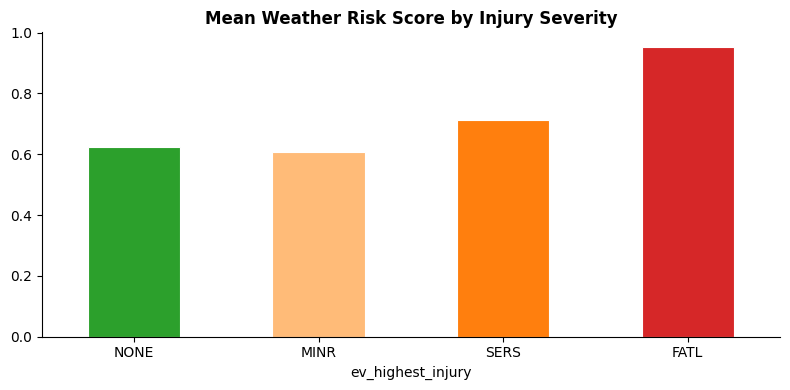

In [12]:
# ── 4.6 Weather severity score (for EDA/dashboard only) ──────────────────
df['weather_risk_score'] = (
    df['adverse_weather'] + df['poor_visibility'] + df['high_wind'] +
    df['extreme_temp'] + df['fog_risk'] + df['is_imc']
)
print('weather_risk_score distribution:')
print(df['weather_risk_score'].value_counts().sort_index())

# Quick EDA plot
fig, ax = plt.subplots(figsize=(8, 4))
order = ['NONE','MINR','SERS','FATL']
df.groupby('ev_highest_injury')['weather_risk_score'].mean()[order].plot(
    kind='bar', ax=ax, color=['#2ca02c','#ffbb78','#ff7f0e','#d62728'],
    edgecolor='white', linewidth=0.8)
ax.set_title('Mean Weather Risk Score by Injury Severity', fontsize=12, fontweight='bold')
ax.set_xticklabels(order, rotation=0)
sns.despine()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/weather_risk_by_severity.png', dpi=150)
plt.show()


## 5. Log Transforms
`log1p` is applied to strongly right-skewed variables (airframe hours, weight, fuel, runway length).
It compresses the long tail so that a handful of very large aircraft do not dominate the scaled
feature; the raw columns are then dropped.

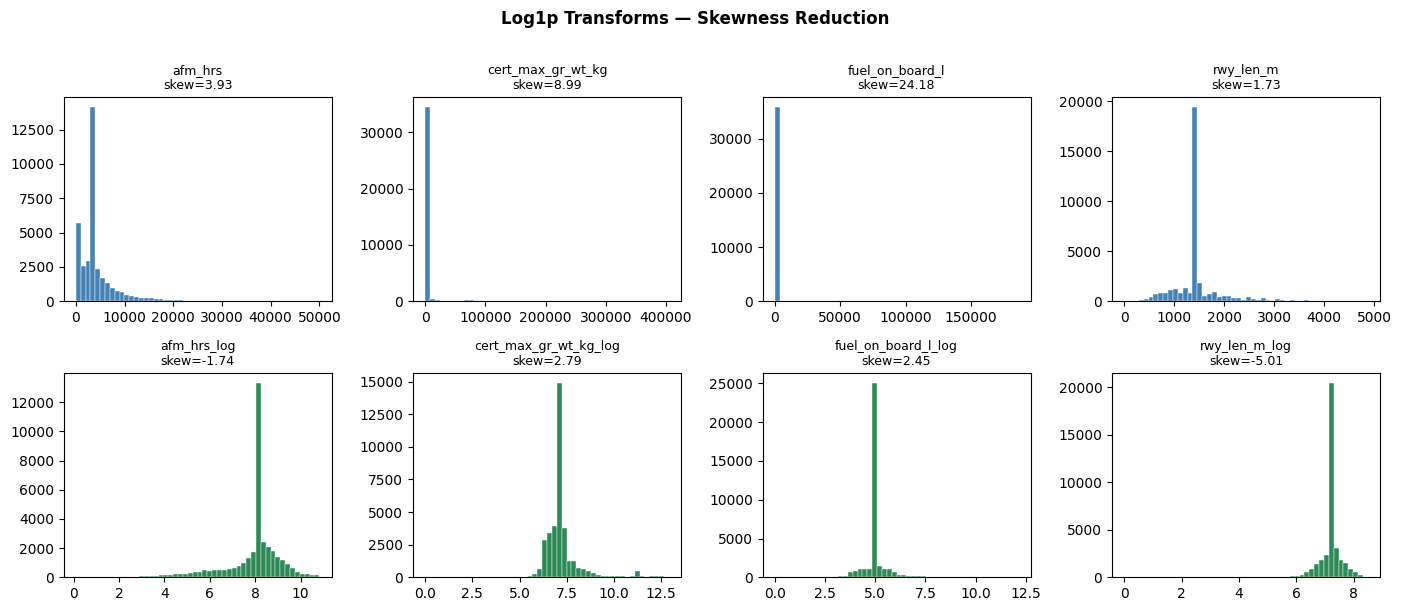

In [13]:
fig, axes = plt.subplots(2, len(LOG_COLS), figsize=(14, 6))
for i, col in enumerate(LOG_COLS):
    raw, logged = df[col].dropna(), df[f'{col}_log'].dropna()
    axes[0, i].hist(raw, bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
    axes[0, i].set_title(f'{col}\nskew={raw.skew():.2f}', fontsize=9)
    axes[1, i].hist(logged, bins=50, color='seagreen', edgecolor='white', linewidth=0.3)
    axes[1, i].set_title(f'{col}_log\nskew={logged.skew():.2f}', fontsize=9)

plt.suptitle('Log1p Transforms — Skewness Reduction', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/log_transforms.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Feature Column Groups & Target-Leakage Audit
Each feature belongs to exactly one preprocessing group (binary Y/N, numeric binary, one-hot,
high-cardinality one-hot, ordinal, numeric). The groups are defined in the shared module.

### Target leakage
The model is meant to estimate the risk of a flight from information available **before the
outcome is known**. Four NTSB fields are filled in by investigators *after* the accident and
directly encode the outcome — they are listed in `LEAKAGE_COLS` and excluded from every group:

| Column | Why it leaks |
|---|---|
| `crew_tox_perf` | toxicology test on the crew — performed during the autopsy |
| `elt_oper` | the emergency locator transmitter fired — a consequence of the impact |
| `latlong_acq` | position *estimated* from the wreckage instead of measured |
| `wx_src_iic` | weather source chosen by the investigator |

In the previous version of this project `crew_tox_perf` was the **#1 feature** of the model:
when it equals `Y`, 96.6 % of events are fatal. Removing these columns lowers the headline
metrics, but the remaining ones are honest.

### Missingness indicators
NB01 created `is_missing_*` flags before imputation. They are also correlated with the outcome:
the NTSB form is less complete when the pilot died (33 % of events are fatal when the pilot's age
is missing, 17 % otherwise). For a real flight these values are known, so the flags would always
be 0 at prediction time — the model would learn "missing data ⇒ severe accident" and push any
incomplete input towards `FATL`. They are therefore **excluded from the features**
(`MISSING_INDICATOR_COLS`); the underlying values are still imputed with the training median.

In [14]:
# Evidence: outcome distribution for each excluded column
excluded = {**{c: 'post-accident' for c in LEAKAGE_COLS},
            **{c: 'missingness' for c in ['is_missing_crew_age', 'is_missing_fuel_on_board',
                                          'is_missing_afm_hrs']}}
audit = pd.concat(
    {col: pd.crosstab(df[col], df[TARGET_COL], normalize='index')[['NONE', 'MINR', 'SERS', 'FATL']]
     for col in excluded},
    names=['column', 'value'],
).round(3)
audit['rows'] = [int((df[c] == v).sum()) for c, v in audit.index]
audit['reason'] = [excluded[c] for c, _ in audit.index]
audit

ev_highest_injury                NONE   MINR   SERS   FATL   rows  \
column                   value                                      
crew_tox_perf            N      0.600  0.152  0.135  0.113  32262   
                         Y      0.014  0.007  0.013  0.966   3998   
elt_oper                 N      0.552  0.118  0.119  0.211  29894   
                         Y      0.458  0.219  0.138  0.185   6366   
latlong_acq              EST    0.287  0.082  0.117  0.514   3882   
                         MEAS   0.566  0.142  0.123  0.170  32378   
wx_src_iic               PILO   0.709  0.165  0.115  0.011   2834   
                         WFAC   0.523  0.134  0.122  0.221  33248   
                         WIT    0.225  0.062  0.140  0.573    178   
is_missing_crew_age      0      0.558  0.147  0.124  0.172  28066   
                         1      0.461  0.097  0.116  0.326   8194   
is_missing_fuel_on_board 0      0.634  0.170  0.110  0.086  13185   
                         1      0.479  0.116  0.129  0.276  23075   
is_missing_afm_hrs       0      0.574  0.153  0.116  0.158  25266   
                         1      0.449  0.096  0.136  0.319  10994   

ev_highest_injury                      reason  
column                   value                 
crew_tox_perf            N      post-accident  
                         Y      post-accident  
elt_oper                 N      post-accident  
                         Y      post-accident  
latlong_acq              EST    post-accident  
                         MEAS   post-accident  
wx_src_iic               PILO   post-accident  
                         WFAC   post-accident  
                         WIT    post-accident  
is_missing_crew_age      0        missingness  
                         1        missingness  
is_missing_fuel_on_board 0        missingness  
                         1        missingness  
is_missing_afm_hrs       0        missingness  
                         1        missingness

In [15]:
# Dropped columns: identifiers, free text, raw sources replaced by derived features,
# the target, the EDA-only score, the post-accident (leaking) variables and the
# missingness indicators.
DROP_COLS = [
    'Aircraft_Key', 'oper_individual_name',
    'acft_make', 'acft_model', 'acft_series', 'rwy_num',
    'elt_manufacturer', 'elt_model',
    'ev_time', 'ev_dow', 'ev_month', 'ev_dow_num', 'ev_hour', 'wx_cond_basic',
    'afm_hrs', 'cert_max_gr_wt_kg', 'fuel_on_board_l', 'rwy_len_m',
    TARGET_COL, 'weather_risk_score',
    *LEAKAGE_COLS, *MISSING_INDICATOR_COLS,
]

FEATURE_GROUPS = {
    'BINARY_YN': BINARY_YN_COLS, 'NUMERIC_BINARY': NUMERIC_BINARY_COLS, 'OHE': OHE_COLS,
    'OHE_HIGH': OHE_HIGH_COLS, 'ORDINAL': ORDINAL_COLS, 'NUMERIC': NUMERIC_COLS,
}
for name, cols in FEATURE_GROUPS.items():
    print(f'{name:15s}: {len(cols):>3} columns')
print(f'{"TOTAL":15s}: {len(FEATURE_COLS):>3} columns')

BINARY_YN      :   9 columns
NUMERIC_BINARY :  10 columns
OHE            :  12 columns
OHE_HIGH       :  11 columns
ORDINAL        :   1 columns
NUMERIC        :  43 columns
TOTAL          :  86 columns


In [16]:
# Sanity check: no column assigned to multiple groups
all_assigned = set(FEATURE_COLS + DROP_COLS)
all_cols = set(df.columns)
unassigned = all_cols - all_assigned
# Unassigned columns are simply not used by the model (e.g. coordinates, directions)
print(f'Unused columns ({len(unassigned)}):', sorted(unassigned))
assert not set(LEAKAGE_COLS) & set(FEATURE_COLS), 'a leaking column is still a feature'

feature_groups = [BINARY_YN_COLS, NUMERIC_BINARY_COLS, OHE_COLS, OHE_HIGH_COLS, ORDINAL_COLS, NUMERIC_COLS]
names = ['BINARY_YN','NUMERIC_BINARY','OHE','OHE_HIGH','ORDINAL','NUMERIC']
for i in range(len(feature_groups)):
    for j in range(i+1, len(feature_groups)):
        overlap = set(feature_groups[i]) & set(feature_groups[j])
        if overlap:
            print(f'WARNING overlap {names[i]} ∩ {names[j]}: {overlap}')
print("Group checks done ✓")

Unused columns (10): ['acft_year', 'apt_dir', 'crew_no', 'dec_latitude', 'dec_longitude', 'dprt_time', 'elt_connected_antenna', 'elt_mounted_aircraft', 'ifr_equipped_cert', 'wx_obs_dir']
Group checks done ✓


## 7. Target Encoding & Temporal Split
The target `ev_highest_injury` is encoded by increasing severity: `NONE=0, MINR=1, SERS=2, FATL=3`.

The split is **temporal**: the model is trained on the past and evaluated on the most recent
years, exactly as it would be used on future flights. Cutting on calendar years keeps every
event of a given year in the same subset.

| Subset | Years | Share | Use |
|---|---|---|---|
| train | 2008 – 2018 | ≈ 62 % | fit the preprocessing pipeline and the models |
| val | 2019 – 2021 | ≈ 16 % | early stopping / model selection (NB04), conformal calibration (NB05) |
| test | 2022 → | ≈ 23 % | touched once, for the final evaluation |

`split_labels()` is also used by `seed_mongo.py` to tag each MongoDB document with its `split`,
so the API can never show test rows.

> Unlike a random stratified split, class proportions now **differ** between subsets: the share
> of fatal accidents drops from 21.4 % (train) and 21.7 % (val) to 17.9 % (test). The test score therefore
> also measures robustness to this drift over time.

In [17]:
y = df[TARGET_COL].map(INJURY_ORDER)
X = select_model_features(df)          # FEATURE_COLS, bool → int, string → object
assert list(X.columns) == FEATURE_COLS

print(f'X shape: {X.shape}')
print(f'y distribution: {dict(y.value_counts().sort_index())}')

X shape: (36260, 86)
y distribution: {0: 19425, 1: 4919, 2: 4420, 3: 7496}


In [18]:
idx_train, idx_val, idx_test = split_positions(df['ev_year'])
X_train, y_train = X.iloc[idx_train], y.iloc[idx_train]
X_val,   y_val   = X.iloc[idx_val],   y.iloc[idx_val]
X_test,  y_test  = X.iloc[idx_test],  y.iloc[idx_test]

for name, idx in [('Train', idx_train), ('Val', idx_val), ('Test', idx_test)]:
    years = df['ev_year'].iloc[idx]
    print(f'{name:5s}: {len(idx):>6,} rows ({len(idx)/len(X)*100:.1f} %)  years {years.min()}–{years.max()}')

Train: 22,329 rows (61.6 %)  years 2008–2018
Val  :  5,717 rows (15.8 %)  years 2019–2021
Test :  8,214 rows (22.7 %)  years 2022–2026


## 8. sklearn Preprocessing Pipeline (ColumnTransformer)
One sub-pipeline per column group, **fitted on the training set only** (no information from
val/test leaks into imputation medians, encoder categories or scaling statistics):

| Group | Imputation | Encoding |
|---|---|---|
| Binary Y/N | most frequent | ordinal (0/1) |
| Numeric binary | constant 0 | — |
| One-hot (low & high cardinality) | most frequent | one-hot, first level dropped, unknown → all zeros |
| Ordinal (`crew_sex`) | most frequent | ordinal |
| Numeric | median | standard scaling |

In [19]:
binary_yn_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
])

binary_num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
])

ohe_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')),
])

ohe_high_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')),
])

ordinal_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
])

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('binary_yn',  binary_yn_transformer,  [c for c in BINARY_YN_COLS     if c in X.columns]),
        ('binary_num', binary_num_transformer, [c for c in NUMERIC_BINARY_COLS if c in X.columns]),
        ('ohe',        ohe_transformer,        [c for c in OHE_COLS            if c in X.columns]),
        ('ohe_high',   ohe_high_transformer,   [c for c in OHE_HIGH_COLS       if c in X.columns]),
        ('ordinal',    ordinal_transformer,    [c for c in ORDINAL_COLS        if c in X.columns]),
        ('numeric',    numeric_transformer,    [c for c in NUMERIC_COLS        if c in X.columns]),
    ],
    remainder='drop',
    verbose_feature_names_out=False
)
print('ColumnTransformer assembled ✓')


ColumnTransformer assembled ✓


In [20]:
# Fit on TRAIN only
preprocessor.fit(X_train)
X_train_processed = preprocessor.transform(X_train)
X_val_processed   = preprocessor.transform(X_val)
X_test_processed  = preprocessor.transform(X_test)

print(f'X_train_processed: {X_train_processed.shape}')
print(f'X_val_processed  : {X_val_processed.shape}')
print(f'X_test_processed : {X_test_processed.shape}')


X_train_processed: (22329, 1325)
X_val_processed  : (5717, 1325)
X_test_processed : (8214, 1325)


In [21]:
try:
    feature_names = preprocessor.get_feature_names_out()
    print(f'Total features after encoding: {len(feature_names)}')
except Exception as e:
    print(f'Could not retrieve feature names: {e}')
    feature_names = None

if feature_names is not None:
    X_train_df = pd.DataFrame(X_train_processed, columns=feature_names)
    X_val_df   = pd.DataFrame(X_val_processed,   columns=feature_names)
    X_test_df  = pd.DataFrame(X_test_processed,  columns=feature_names)
else:
    X_train_df = pd.DataFrame(X_train_processed)
    X_val_df   = pd.DataFrame(X_val_processed)
    X_test_df  = pd.DataFrame(X_test_processed)


Total features after encoding: 1325


## 9. VarianceThreshold — Remove Near-Zero Variance Features

In [22]:
vt = VarianceThreshold(threshold=1e-4)
X_train_vt = vt.fit_transform(X_train_processed)
X_val_vt   = vt.transform(X_val_processed)
X_test_vt  = vt.transform(X_test_processed)

if feature_names is not None:
    feature_names_vt = [feature_names[i] for i in range(len(feature_names)) if vt.get_support()[i]]
else:
    feature_names_vt = None

print(f"Before VarianceThreshold : {X_train_processed.shape[1]} features")
print(f"After  VarianceThreshold : {X_train_vt.shape[1]} features")
print(f"Removed                  : {X_train_processed.shape[1] - X_train_vt.shape[1]} features")


Before VarianceThreshold : 1325 features
After  VarianceThreshold : 375 features
Removed                  : 950 features


## 10. Sanity Checks
No missing / infinite values after preprocessing, and class proportions per subset (they differ slightly because the split is temporal).

In [23]:
label_map = {0:'NONE',1:'MINR',2:'SERS',3:'FATL'}

for name, arr in [('X_train',X_train_vt),('X_val',X_val_vt),('X_test',X_test_vt)]:
    nans = np.isnan(arr).sum()
    infs = np.isinf(arr).sum()
    print(f'{name}: NaNs={nans}  Infs={infs}  {"✓" if nans+infs==0 else "WARNING"}')

print('\nTarget distribution verification (%):')
for name, y_split in [('train',y_train),('val',y_val),('test',y_test)]:
    dist = (y_split.value_counts(normalize=True).sort_index() * 100).round(1)
    dist.index = [label_map[i] for i in dist.index]
    print(f'  {name}: {dict(dist)}')


X_train: NaNs=0  Infs=0  ✓
X_val: NaNs=0  Infs=0  ✓


X_test: NaNs=0  Infs=0  ✓

Target distribution verification (%):
  train: {'NONE': 53.0, 'MINR': 13.8, 'SERS': 11.8, 'FATL': 21.4}
  val: {'NONE': 52.6, 'MINR': 12.9, 'SERS': 12.7, 'FATL': 21.7}
  test: {'NONE': 55.8, 'MINR': 13.4, 'SERS': 12.9, 'FATL': 17.9}


## 11. Class Weights

In [24]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

print('Class weights (pass to model class_weight parameter):')
for k, v in class_weight_dict.items():
    print(f'  {label_map[k]}: {v:.4f}')


Class weights (pass to model class_weight parameter):
  NONE: 0.4720
  MINR: 1.8154
  SERS: 2.1169
  FATL: 1.1656


## 12. Save Artefacts

In [25]:
X_train_df_vt = pd.DataFrame(X_train_vt, columns=feature_names_vt)
X_val_df_vt   = pd.DataFrame(X_val_vt,   columns=feature_names_vt)
X_test_df_vt  = pd.DataFrame(X_test_vt,  columns=feature_names_vt)

X_train_df_vt.to_csv(f'{OUTPUT_DIR}/X_train.csv', index=False)
X_val_df_vt.to_csv(f'{OUTPUT_DIR}/X_val.csv',     index=False)
X_test_df_vt.to_csv(f'{OUTPUT_DIR}/X_test.csv',   index=False)

y_train.to_csv(f'{OUTPUT_DIR}/y_train.csv', index=False)
y_val.to_csv(f'{OUTPUT_DIR}/y_val.csv',     index=False)
y_test.to_csv(f'{OUTPUT_DIR}/y_test.csv',   index=False)

joblib.dump(preprocessor,     f'{OUTPUT_DIR}/preprocessing_pipeline.pkl')
joblib.dump(vt,               f'{OUTPUT_DIR}/variance_threshold.pkl')
joblib.dump(class_weight_dict,f'{OUTPUT_DIR}/class_weights.pkl')

if feature_names_vt:
    pd.Series(feature_names_vt).to_csv(f'{OUTPUT_DIR}/feature_names.csv', index=False)

print("All artefacts saved to outputs/")


All artefacts saved to outputs/
